In [2]:
import sqlite3
import pandas as pd
import os

# Путь к SQLite-базе
db_path = "/content/olist.db"

# Создаём подключение к базе данных
conn = sqlite3.connect(db_path)

# Название таблицы → название CSV-файла
tables = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv"
}

# Загружаем каждый CSV в отдельную таблицу SQLite
for table_name, file_name in tables.items():

    file_path = os.path.join("/content", file_name)

    data = pd.read_csv(file_path)

    data.to_sql(
        table_name,
        conn,
        if_exists="replace",
        index=False
    )

    print(
        f"{table_name:22} | "
        f"строк: {len(data):,} | "
        f"столбцов: {len(data.columns)}"
    )

print("\nSQLite-база успешно создана!")
print("Путь:", db_path)

customers              | строк: 99,441 | столбцов: 5
geolocation            | строк: 1,000,163 | столбцов: 5
order_items            | строк: 112,650 | столбцов: 7
order_payments         | строк: 103,886 | столбцов: 5
order_reviews          | строк: 99,224 | столбцов: 7
orders                 | строк: 99,441 | столбцов: 8
products               | строк: 32,951 | столбцов: 9
sellers                | строк: 3,095 | столбцов: 4
category_translation   | строк: 71 | столбцов: 2

SQLite-база успешно создана!
Путь: /content/olist.db


In [3]:
# Проверяем, какие таблицы находятся в базе данных

tables_in_db = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
    """,
    conn
)

print("Таблицы в SQLite:")
print(tables_in_db.to_string(index=False))

Таблицы в SQLite:
                name
category_translation
           customers
         geolocation
         order_items
      order_payments
       order_reviews
              orders
            products
             sellers


In [4]:
queries = {
    "Заказы и клиенты": """
        SELECT
            o.order_id,
            o.customer_id,
            c.customer_unique_id,
            c.customer_city,
            c.customer_state
        FROM orders o
        LEFT JOIN customers c
            ON o.customer_id = c.customer_id
        LIMIT 5;
    """,

    "Заказы и отзывы": """
        SELECT
            o.order_id,
            o.order_status,
            r.review_score
        FROM orders o
        LEFT JOIN order_reviews r
            ON o.order_id = r.order_id
        LIMIT 5;
    """,

    "Заказы и товары": """
        SELECT
            oi.order_id,
            oi.product_id,
            oi.seller_id,
            oi.price,
            oi.freight_value
        FROM order_items oi
        LIMIT 5;
    """,

    "Товары и продавцы": """
        SELECT
            oi.product_id,
            oi.seller_id,
            p.product_category_name,
            s.seller_city,
            s.seller_state
        FROM order_items oi
        LEFT JOIN products p
            ON oi.product_id = p.product_id
        LEFT JOIN sellers s
            ON oi.seller_id = s.seller_id
        LIMIT 5;
    """
}

for query_name, query in queries.items():
    print(f"\n{'=' * 60}")
    print(query_name)
    print('=' * 60)

    result = pd.read_sql_query(query, conn)
    display(result)


Заказы и клиенты


,order_id,customer_id,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP



Заказы и отзывы


,order_id,order_status,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,4
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,4
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,5
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,5
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,5



Заказы и товары


,order_id,product_id,seller_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14



Товары и продавцы


,product_id,seller_id,product_category_name,seller_city,seller_state
0,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,cool_stuff,volta redonda,SP
1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop,sao paulo,SP
2,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,moveis_decoracao,borda da mata,MG
3,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,perfumaria,franca,SP
4,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,ferramentas_jardim,loanda,PR


In [5]:
# Формируем аналитический датасет на уровне заказа
# Все основные агрегации выполняются непосредственно в SQL

query = """
WITH item_features AS (
    SELECT
        oi.order_id,

        COUNT(*) AS number_of_items,
        COUNT(DISTINCT oi.seller_id) AS number_of_sellers,
        COUNT(DISTINCT p.product_category_name) AS number_of_categories,

        SUM(oi.price) AS total_price,
        SUM(oi.freight_value) AS total_freight,

        AVG(oi.price) AS avg_item_price,
        AVG(oi.freight_value) AS avg_freight_value,

        AVG(p.product_weight_g) AS avg_product_weight,
        AVG(p.product_photos_qty) AS avg_product_photos

    FROM order_items oi

    LEFT JOIN products p
        ON oi.product_id = p.product_id

    GROUP BY oi.order_id
),

payment_features AS (
    SELECT
        order_id,

        COUNT(*) AS number_of_payments,
        MAX(payment_installments) AS max_installments,
        SUM(payment_value) AS total_payment_value,

        GROUP_CONCAT(
            DISTINCT payment_type
        ) AS payment_types

    FROM order_payments

    GROUP BY order_id
)

SELECT
    o.order_id,
    o.customer_id,

    o.order_status,

    o.order_purchase_timestamp,
    o.order_approved_at,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    c.customer_unique_id,
    c.customer_city,
    c.customer_state,

    i.number_of_items,
    i.number_of_sellers,
    i.number_of_categories,

    i.total_price,
    i.total_freight,

    i.total_price + i.total_freight AS total_order_value,

    i.avg_item_price,
    i.avg_freight_value,

    i.avg_product_weight,
    i.avg_product_photos,

    p.number_of_payments,
    p.max_installments,
    p.total_payment_value,
    p.payment_types,

    r.review_score

FROM orders o

LEFT JOIN customers c
    ON o.customer_id = c.customer_id

LEFT JOIN item_features i
    ON o.order_id = i.order_id

LEFT JOIN payment_features p
    ON o.order_id = p.order_id

LEFT JOIN order_reviews r
    ON o.order_id = r.order_id
"""

df_sql = pd.read_sql_query(query, conn)

print("Размер аналитического датасета:", df_sql.shape)
print()

display(df_sql.head())

Размер аналитического датасета: (99992, 26)



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,total_order_value,avg_item_price,avg_freight_value,avg_product_weight,avg_product_photos,number_of_payments,max_installments,total_payment_value,payment_types,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,38.71,29.99,8.72,500.0,4.0,3.0,1.0,38.71,"credit_card,voucher",4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,barreiras,...,141.46,118.70,22.76,400.0,1.0,1.0,1.0,141.46,boleto,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,179.12,159.90,19.22,420.0,1.0,1.0,3.0,179.12,credit_card,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,72.20,45.00,27.20,450.0,3.0,1.0,1.0,72.20,credit_card,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,28.62,19.90,8.72,250.0,4.0,1.0,1.0,28.62,credit_card,5.0


In [6]:
# Проверяем уникальность заказов

print("Всего строк:", len(df_sql))
print("Уникальных order_id:", df_sql["order_id"].nunique())
print(
    "Количество дубликатов order_id:",
    df_sql["order_id"].duplicated().sum()
)

print("\nКоличество пропусков по признакам:")

missing = (
    df_sql.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_percent = (
    df_sql.isnull()
    .mean()
    .mul(100)
    .round(2)
)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

display(
    missing_table[
        missing_table["missing_count"] > 0
    ]
)

Всего строк: 99992
Уникальных order_id: 99441
Количество дубликатов order_id: 551

Количество пропусков по признакам:


,missing_count,missing_percent
avg_freight_value,778,0.78
avg_item_price,778,0.78
avg_product_photos,2176,2.18
avg_product_weight,794,0.79
max_installments,1,0.00
number_of_categories,778,0.78
number_of_items,778,0.78
number_of_payments,1,0.00
number_of_sellers,778,0.78
order_approved_at,161,0.16


In [8]:
# Исправленный SQL-запрос
# Цель: получить одну строку на один заказ

query = """
WITH item_features AS (
    SELECT
        oi.order_id,

        COUNT(*) AS number_of_items,
        COUNT(DISTINCT oi.seller_id) AS number_of_sellers,
        COUNT(DISTINCT p.product_category_name) AS number_of_categories,

        SUM(oi.price) AS total_price,
        SUM(oi.freight_value) AS total_freight,

        AVG(oi.price) AS avg_item_price,
        AVG(oi.freight_value) AS avg_freight_value,

        AVG(p.product_weight_g) AS avg_product_weight,
        AVG(p.product_photos_qty) AS avg_product_photos

    FROM order_items oi

    LEFT JOIN products p
        ON oi.product_id = p.product_id

    GROUP BY oi.order_id
),

payment_features AS (
    SELECT
        order_id,

        COUNT(*) AS number_of_payments,
        MAX(payment_installments) AS max_installments,
        SUM(payment_value) AS total_payment_value,
        GROUP_CONCAT(DISTINCT payment_type) AS payment_types

    FROM order_payments

    GROUP BY order_id
),

review_features AS (
    SELECT
        order_id,
        AVG(review_score) AS review_score

    FROM order_reviews

    GROUP BY order_id
)

SELECT
    o.order_id,
    o.customer_id,
    o.order_status,

    o.order_purchase_timestamp,
    o.order_approved_at,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    c.customer_unique_id,
    c.customer_city,
    c.customer_state,

    i.number_of_items,
    i.number_of_sellers,
    i.number_of_categories,

    i.total_price,
    i.total_freight,
    i.total_price + i.total_freight AS total_order_value,

    i.avg_item_price,
    i.avg_freight_value,
    i.avg_product_weight,
    i.avg_product_photos,

    p.number_of_payments,
    p.max_installments,
    p.total_payment_value,
    p.payment_types,

    r.review_score

FROM orders o

LEFT JOIN customers c
    ON o.customer_id = c.customer_id

LEFT JOIN item_features i
    ON o.order_id = i.order_id

LEFT JOIN payment_features p
    ON o.order_id = p.order_id

LEFT JOIN review_features r
    ON o.order_id = r.order_id
"""

df_sql = pd.read_sql_query(query, conn)

print("Размер аналитического датасета:", df_sql.shape)
print("Всего строк:", len(df_sql))
print("Уникальных order_id:", df_sql["order_id"].nunique())
print(
    "Количество дубликатов order_id:",
    df_sql["order_id"].duplicated().sum()
)

Размер аналитического датасета: (99441, 26)
Всего строк: 99441
Уникальных order_id: 99441
Количество дубликатов order_id: 0


In [9]:
# Сохраняем результат SQL-агрегации

output_path = "/content/df_sql_ready.csv"

df_sql.to_csv(
    output_path,
    index=False
)

print("Аналитический датасет сохранён:")
print(output_path)
print()
print("Размер:", df_sql.shape)

Аналитический датасет сохранён:
/content/df_sql_ready.csv

Размер: (99441, 26)


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем результат SQL-агрегации
df = pd.read_csv("/content/df_sql_ready.csv")

print("Исходный размер датасета:", df.shape)

# Оставляем только доставленные заказы
df_model = df[df["order_status"] == "delivered"].copy()

print("Размер после фильтрации:", df_model.shape)
print("Количество доставленных заказов:", len(df_model))

Исходный размер датасета: (99441, 26)
Размер после фильтрации: (96478, 26)
Количество доставленных заказов: 96478


In [12]:
# Преобразуем даты в формат datetime

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    df_model[col] = pd.to_datetime(
        df_model[col],
        errors="coerce"
    )

# Фактическая длительность доставки в днях
df_model["delivery_time_days"] = (
    df_model["order_delivered_customer_date"]
    - df_model["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)

# Отклонение от обещанной даты доставки
# Положительное значение = опоздание
# Отрицательное значение = доставка раньше срока
df_model["delivery_delay_days"] = (
    df_model["order_delivered_customer_date"]
    - df_model["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 3600)

print("Признаки доставки успешно созданы.")

Признаки доставки успешно созданы.


In [13]:
# Проверяем признаки доставки

display(
    df_model[
        [
            "order_id",
            "delivery_time_days",
            "delivery_delay_days"
        ]
    ].head(10)
)

print("Статистика признаков доставки:")

display(
    df_model[
        [
            "delivery_time_days",
            "delivery_delay_days"
        ]
    ].describe()
)

print("Количество пропусков:")

print(
    df_model[
        [
            "delivery_time_days",
            "delivery_delay_days"
        ]
    ].isna().sum()
)

,order_id,delivery_time_days,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,-7.107488
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,-5.355729
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,-17.245498
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,-12.980069
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,-9.238171
5,a4591c265e18cb1dcee52889e2d8acc3,16.542245,-5.543113
7,6514b8ad8028c9f2cc2374ded245783f,9.989826,-11.461215
8,76c6e866289321a7c93b82b54852dc33,9.818762,-31.410995
9,e69bfb5eb88e0ed6a785585b27e16dbf,18.221852,-6.281597
10,e6ce16cb79ec1d90b1da9085a6118aeb,12.650937,-8.528808


Статистика признаков доставки:


,delivery_time_days,delivery_delay_days
count,96470.000000,96470.000000
mean,12.558217,-11.178126
std,9.546156,10.184354
min,0.533414,-146.016123
25%,6.766204,-16.244065
50%,10.217477,-11.948102
75%,15.720182,-6.389815
max,209.628611,188.975081


Количество пропусков:
delivery_time_days     8
delivery_delay_days    8
dtype: int64


In [14]:
# Создаём целевую переменную
# 1 = низкая оценка (1–2 звезды)
# 0 = оценка 3–5 звёзд

df_model["bad_review"] = (
    df_model["review_score"] <= 2
).astype(int)

print("Распределение целевой переменной:")
print(df_model["bad_review"].value_counts())

print("\nРаспределение в процентах:")
print(
    df_model["bad_review"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nРаспределение исходных оценок:")
print(
    df_model["review_score"]
    .value_counts()
    .sort_index()
)

Распределение целевой переменной:
bad_review
0    84241
1    12237
Name: count, dtype: int64

Распределение в процентах:
bad_review
0    87.32
1    12.68
Name: proportion, dtype: float64

Распределение исходных оценок:
review_score
1.000000     9313
1.500000        8
2.000000     2916
2.500000       30
3.000000     7915
3.333333        1
3.500000       23
4.000000    18868
4.333333        1
4.500000       53
5.000000    56704
Name: count, dtype: int64


In [15]:
# Проверяем, есть ли заказы с несколькими отзывами

review_duplicates = pd.read_sql_query("""
    SELECT
        order_id,
        COUNT(*) AS review_count
    FROM order_reviews
    GROUP BY order_id
    HAVING COUNT(*) > 1
    ORDER BY review_count DESC
""", conn)

print("Заказов с несколькими отзывами:", len(review_duplicates))

display(review_duplicates.head(10))

Заказов с несколькими отзывами: 547


,order_id,review_count
0,df56136b8031ecd28e200bb18e6ddb2e,3
1,c88b1d1b157a9999ce368f218a407141,3
2,8e17072ec97ce29f0e1f111e598b0c85,3
3,03c939fd7fd3b38f8485a0f95798f1f6,3
4,ffaabba06c9d293a3c614e0515ddbabc,2
5,ff850ba359507b996e8b2fbb26df8d03,2
6,ff763b73e473d03c321bcd5a053316e8,2
7,fe041ba1c9f54016432fa6ee91709dbc,2
8,fd95ae805c63c534f1a64589e102225e,2
9,fd61441ba2a7b57e6342862e779b10b0,2


In [16]:
# Финальный SQL-запрос для аналитического датасета
# Одна строка = один заказ

query = """
WITH item_features AS (
    SELECT
        oi.order_id,

        COUNT(*) AS number_of_items,
        COUNT(DISTINCT oi.seller_id) AS number_of_sellers,
        COUNT(DISTINCT p.product_category_name) AS number_of_categories,

        SUM(oi.price) AS total_price,
        SUM(oi.freight_value) AS total_freight,

        AVG(oi.price) AS avg_item_price,
        AVG(oi.freight_value) AS avg_freight_value,

        AVG(p.product_weight_g) AS avg_product_weight,
        AVG(p.product_photos_qty) AS avg_product_photos

    FROM order_items oi

    LEFT JOIN products p
        ON oi.product_id = p.product_id

    GROUP BY oi.order_id
),

payment_features AS (
    SELECT
        order_id,

        COUNT(*) AS number_of_payments,
        MAX(payment_installments) AS max_installments,
        SUM(payment_value) AS total_payment_value,

        GROUP_CONCAT(DISTINCT payment_type) AS payment_types

    FROM order_payments

    GROUP BY order_id
),

review_features AS (
    SELECT
        order_id,

        MAX(review_score) AS review_score,

        MAX(
            CASE
                WHEN review_score <= 2 THEN 1
                ELSE 0
            END
        ) AS bad_review

    FROM order_reviews

    GROUP BY order_id
)

SELECT
    o.order_id,
    o.customer_id,
    o.order_status,

    o.order_purchase_timestamp,
    o.order_approved_at,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    c.customer_unique_id,
    c.customer_city,
    c.customer_state,

    i.number_of_items,
    i.number_of_sellers,
    i.number_of_categories,

    i.total_price,
    i.total_freight,
    i.total_price + i.total_freight AS total_order_value,

    i.avg_item_price,
    i.avg_freight_value,
    i.avg_product_weight,
    i.avg_product_photos,

    p.number_of_payments,
    p.max_installments,
    p.total_payment_value,
    p.payment_types,

    r.review_score,
    r.bad_review

FROM orders o

LEFT JOIN customers c
    ON o.customer_id = c.customer_id

LEFT JOIN item_features i
    ON o.order_id = i.order_id

LEFT JOIN payment_features p
    ON o.order_id = p.order_id

LEFT JOIN review_features r
    ON o.order_id = r.order_id
"""

df_sql = pd.read_sql_query(query, conn)

print("Размер аналитического датасета:", df_sql.shape)
print("Всего строк:", len(df_sql))
print("Уникальных order_id:", df_sql["order_id"].nunique())
print(
    "Количество дубликатов order_id:",
    df_sql["order_id"].duplicated().sum()
)

print("\nРаспределение review_score:")
print(df_sql["review_score"].value_counts().sort_index())

print("\nРаспределение bad_review:")
print(df_sql["bad_review"].value_counts(dropna=False))

Размер аналитического датасета: (99441, 27)
Всего строк: 99441
Уникальных order_id: 99441
Количество дубликатов order_id: 0

Распределение review_score:
review_score
1.0    11316
2.0     3121
3.0     8116
4.0    19044
5.0    57076
Name: count, dtype: int64

Распределение bad_review:
bad_review
0.0    84140
1.0    14533
NaN      768
Name: count, dtype: int64


In [17]:
# Распределение клиентских оценок

review_distribution = (
    df_model["review_score"]
    .value_counts()
    .sort_index()
)

print("Распределение оценок:")
print(review_distribution)

print("\nРаспределение в процентах:")
print(
    (review_distribution / review_distribution.sum() * 100)
    .round(2)
)

Распределение оценок:
review_score
1.000000     9313
1.500000        8
2.000000     2916
2.500000       30
3.000000     7915
3.333333        1
3.500000       23
4.000000    18868
4.333333        1
4.500000       53
5.000000    56704
Name: count, dtype: int64

Распределение в процентах:
review_score
1.000000     9.72
1.500000     0.01
2.000000     3.04
2.500000     0.03
3.000000     8.26
3.333333     0.00
3.500000     0.02
4.000000    19.69
4.333333     0.00
4.500000     0.06
5.000000    59.17
Name: count, dtype: float64


In [18]:
# Проверяем исходную таблицу отзывов

review_scores = pd.read_sql_query("""
    SELECT
        review_score,
        COUNT(*) AS review_count
    FROM order_reviews
    GROUP BY review_score
    ORDER BY review_score
""", conn)

display(review_scores)

,review_score,review_count
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


In [19]:
# Финальная агрегация отзывов
# Один заказ = одна строка
# bad_review = 1, если хотя бы один отзыв имеет 1–2 звезды

review_features = pd.read_sql_query("""
    SELECT
        order_id,

        MIN(review_score) AS review_score,

        CASE
            WHEN MIN(review_score) <= 2 THEN 1
            ELSE 0
        END AS bad_review

    FROM order_reviews

    GROUP BY order_id
""", conn)

print("Размер:", review_features.shape)
print("Уникальных заказов:", review_features["order_id"].nunique())
print("Дубликатов:", review_features["order_id"].duplicated().sum())

print("\nРаспределение review_score:")
print(review_features["review_score"].value_counts().sort_index())

print("\nРаспределение bad_review:")
print(review_features["bad_review"].value_counts())

Размер: (98673, 3)
Уникальных заказов: 98673
Дубликатов: 0

Распределение review_score:
review_score
1    11393
2     3140
3     8138
4    19047
5    56955
Name: count, dtype: int64

Распределение bad_review:
bad_review
0    84140
1    14533
Name: count, dtype: int64


In [20]:
# Финальный аналитический датасет
# Один order_id = одна строка

query_final = """
WITH item_features AS (
    SELECT
        oi.order_id,

        COUNT(*) AS number_of_items,
        COUNT(DISTINCT oi.seller_id) AS number_of_sellers,
        COUNT(DISTINCT p.product_category_name) AS number_of_categories,

        SUM(oi.price) AS total_price,
        SUM(oi.freight_value) AS total_freight,

        AVG(oi.price) AS avg_item_price,
        AVG(oi.freight_value) AS avg_freight_value,

        AVG(p.product_weight_g) AS avg_product_weight,
        AVG(p.product_photos_qty) AS avg_product_photos

    FROM order_items oi

    LEFT JOIN products p
        ON oi.product_id = p.product_id

    GROUP BY oi.order_id
),

payment_features AS (
    SELECT
        order_id,

        COUNT(*) AS number_of_payments,
        MAX(payment_installments) AS max_installments,
        SUM(payment_value) AS total_payment_value,

        GROUP_CONCAT(DISTINCT payment_type) AS payment_types

    FROM order_payments

    GROUP BY order_id
),

review_features AS (
    SELECT
        order_id,

        MIN(review_score) AS review_score,

        CASE
            WHEN MIN(review_score) <= 2 THEN 1
            ELSE 0
        END AS bad_review

    FROM order_reviews

    GROUP BY order_id
)

SELECT
    o.order_id,
    o.customer_id,
    o.order_status,

    o.order_purchase_timestamp,
    o.order_approved_at,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    c.customer_unique_id,
    c.customer_city,
    c.customer_state,

    i.number_of_items,
    i.number_of_sellers,
    i.number_of_categories,

    i.total_price,
    i.total_freight,
    i.total_price + i.total_freight AS total_order_value,

    i.avg_item_price,
    i.avg_freight_value,
    i.avg_product_weight,
    i.avg_product_photos,

    p.number_of_payments,
    p.max_installments,
    p.total_payment_value,
    p.payment_types,

    r.review_score,
    r.bad_review

FROM orders o

LEFT JOIN customers c
    ON o.customer_id = c.customer_id

LEFT JOIN item_features i
    ON o.order_id = i.order_id

LEFT JOIN payment_features p
    ON o.order_id = p.order_id

LEFT JOIN review_features r
    ON o.order_id = r.order_id
"""

df_sql = pd.read_sql_query(query_final, conn)

print("Размер аналитического датасета:", df_sql.shape)
print("Всего строк:", len(df_sql))
print("Уникальных order_id:", df_sql["order_id"].nunique())
print(
    "Дубликатов order_id:",
    df_sql["order_id"].duplicated().sum()
)

print("\nРаспределение review_score:")
print(df_sql["review_score"].value_counts(dropna=False).sort_index())

print("\nРаспределение bad_review:")
print(df_sql["bad_review"].value_counts(dropna=False).sort_index())

Размер аналитического датасета: (99441, 27)
Всего строк: 99441
Уникальных order_id: 99441
Дубликатов order_id: 0

Распределение review_score:
review_score
1.0    11393
2.0     3140
3.0     8138
4.0    19047
5.0    56955
NaN      768
Name: count, dtype: int64

Распределение bad_review:
bad_review
0.0    84140
1.0    14533
NaN      768
Name: count, dtype: int64


In [21]:
# Сохраняем финальный аналитический датасет

df_sql.to_csv(
    "/content/df_sql_ready.csv",
    index=False
)

print("Финальный аналитический датасет сохранён:")
print("/content/df_sql_ready.csv")
print("Размер:", df_sql.shape)

Финальный аналитический датасет сохранён:
/content/df_sql_ready.csv
Размер: (99441, 27)


In [22]:
# Оставляем только доставленные заказы

df_model = df_sql[
    df_sql["order_status"] == "delivered"
].copy()

print("Доставленных заказов:", len(df_model))

# Убираем заказы без отзыва,
# поскольку для них неизвестна целевая переменная

df_model = df_model[
    df_model["bad_review"].notna()
].copy()

print("Доставленных заказов с отзывом:", len(df_model))

# Приводим целевую переменную к целому типу
df_model["bad_review"] = df_model["bad_review"].astype(int)

print("\nРаспределение целевой переменной:")
print(df_model["bad_review"].value_counts())

print("\nРаспределение в процентах:")
print(
    df_model["bad_review"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Доставленных заказов: 96478
Доставленных заказов с отзывом: 95832

Распределение целевой переменной:
bad_review
0    83521
1    12311
Name: count, dtype: int64

Распределение в процентах:
bad_review
0    87.15
1    12.85
Name: proportion, dtype: float64


In [23]:
# Анализ пропущенных значений

missing_analysis = (
    df_model.isnull()
    .sum()
    .to_frame("missing_count")
)

missing_analysis["missing_percent"] = (
    missing_analysis["missing_count"]
    / len(df_model)
    * 100
).round(2)

missing_analysis = (
    missing_analysis
    .sort_values("missing_count", ascending=False)
)

display(
    missing_analysis[
        missing_analysis["missing_count"] > 0
    ]
)

,missing_count,missing_percent
avg_product_photos,1324,1.38
avg_product_weight,16,0.02
order_approved_at,14,0.01
order_delivered_customer_date,8,0.01
order_delivered_carrier_date,2,0.00
number_of_payments,1,0.00
max_installments,1,0.00
total_payment_value,1,0.00
payment_types,1,0.00


In [24]:
# Распределение оценок клиентов

review_distribution = (
    df_model["review_score"]
    .value_counts()
    .sort_index()
)

print("Распределение оценок:")
print(review_distribution)

print("\nРаспределение в процентах:")
print(
    (review_distribution / review_distribution.sum() * 100)
    .round(2)
)

Распределение оценок:
review_score
1.0     9381
2.0     2930
3.0     7920
4.0    18897
5.0    56704
Name: count, dtype: int64

Распределение в процентах:
review_score
1.0     9.79
2.0     3.06
3.0     8.26
4.0    19.72
5.0    59.17
Name: count, dtype: float64


In [25]:
# Преобразуем даты

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    df_model[col] = pd.to_datetime(
        df_model[col],
        errors="coerce"
    )

# Фактическая длительность доставки
df_model["delivery_time_days"] = (
    df_model["order_delivered_customer_date"]
    - df_model["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)

# Отклонение от обещанной даты
df_model["delivery_delay_days"] = (
    df_model["order_delivered_customer_date"]
    - df_model["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 3600)

print("Признаки доставки созданы.")

Признаки доставки созданы.


In [26]:
# Группируем заказы по величине задержки

df_model["delay_group"] = pd.cut(
    df_model["delivery_delay_days"],
    bins=[
        -float("inf"),
        -14,
        -7,
        0,
        7,
        14,
        float("inf")
    ],
    labels=[
        "Более 14 дней раньше",
        "8–14 дней раньше",
        "1–7 дней раньше",
        "До 7 дней опоздания",
        "8–14 дней опоздания",
        "Более 14 дней опоздания"
    ]
)

delay_analysis = (
    df_model
    .groupby("delay_group", observed=False)["bad_review"]
    .agg(["count", "mean"])
    .reset_index()
)

delay_analysis["bad_review_percent"] = (
    delay_analysis["mean"] * 100
).round(2)

display(delay_analysis)



,delay_group,count,mean,bad_review_percent
0,Более 14 дней раньше,34771,0.090967,9.10
1,8–14 дней раньше,36158,0.089330,8.93
2,1–7 дней раньше,17234,0.102762,10.28
3,До 7 дней опоздания,4409,0.361306,36.13
4,8–14 дней опоздания,1748,0.782037,78.20
5,Более 14 дней опоздания,1504,0.788564,78.86


Между отклонением фактической даты доставки от ожидаемой и вероятностью низкой оценки наблюдается выраженная связь. Для заказов, доставленных раньше ожидаемой даты, доля низких оценок находится примерно в диапазоне 8.93–10.28%. При опоздании до 7 дней этот показатель увеличивается до 36.13%, а при опоздании на 8–14 дней — до 78.20%. Для заказов, доставленных более чем на 14 дней позже ожидаемой даты, доля низких оценок составляет 78.86%.

Таким образом, задержка относительно обещанной даты является потенциально важным фактором негативного клиентского опыта. При этом данный анализ показывает статистическую связь и не позволяет самостоятельно сделать вывод о причинно-следственной зависимости.

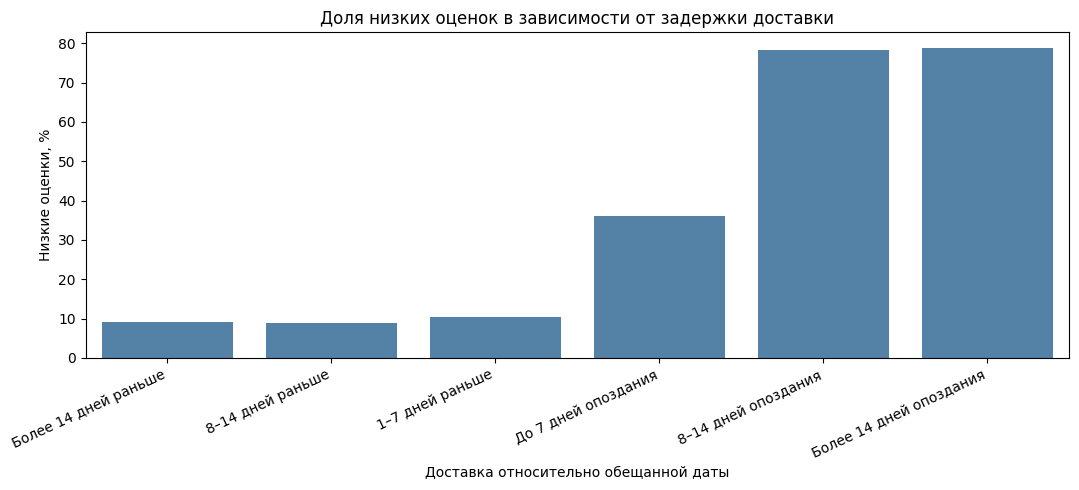

In [27]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=delay_analysis,
    x="delay_group",
    y="bad_review_percent",
    color="steelblue"
)

plt.title(
    "Доля низких оценок в зависимости от задержки доставки"
)
plt.xlabel("Доставка относительно обещанной даты")
plt.ylabel("Низкие оценки, %")

plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

In [28]:
# Группировка заказов по фактической длительности доставки

df_model["delivery_time_group"] = pd.cut(
    df_model["delivery_time_days"],
    bins=[
        0,
        5,
        10,
        15,
        20,
        30,
        60,
        float("inf")
    ],
    labels=[
        "0–5 дней",
        "6–10 дней",
        "11–15 дней",
        "16–20 дней",
        "21–30 дней",
        "31–60 дней",
        "60+ дней"
    ]
)

delivery_time_analysis = (
    df_model
    .groupby(
        "delivery_time_group",
        observed=False
    )["bad_review"]
    .agg(["count", "mean"])
    .reset_index()
)

delivery_time_analysis["bad_review_percent"] = (
    delivery_time_analysis["mean"] * 100
).round(2)

display(delivery_time_analysis)

,delivery_time_group,count,mean,bad_review_percent
0,0–5 дней,13374,0.071407,7.14
1,6–10 дней,32885,0.082226,8.22
2,11–15 дней,23470,0.095910,9.59
3,16–20 дней,12077,0.120808,12.08
4,21–30 дней,9588,0.223926,22.39
5,31–60 дней,4139,0.628413,62.84
6,60+ дней,291,0.663230,66.32


Наблюдается выраженная связь между фактической длительностью доставки и долей низких оценок. Для заказов, доставленных за 0–5 дней, доля оценок 1–2 звезды составляет 7.14%. При увеличении длительности доставки до 21–30 дней показатель возрастает до 22.39%, а для заказов с длительностью 31–60 дней достигает 62.84%. Для категории более 60 дней доля низких оценок составляет 66.32%.

Таким образом, более длительная доставка связана с большей долей негативных оценок. Однако, как и в предыдущем анализе, эти результаты отражают статистическую связь и не доказывают причинно-следственную зависимость.

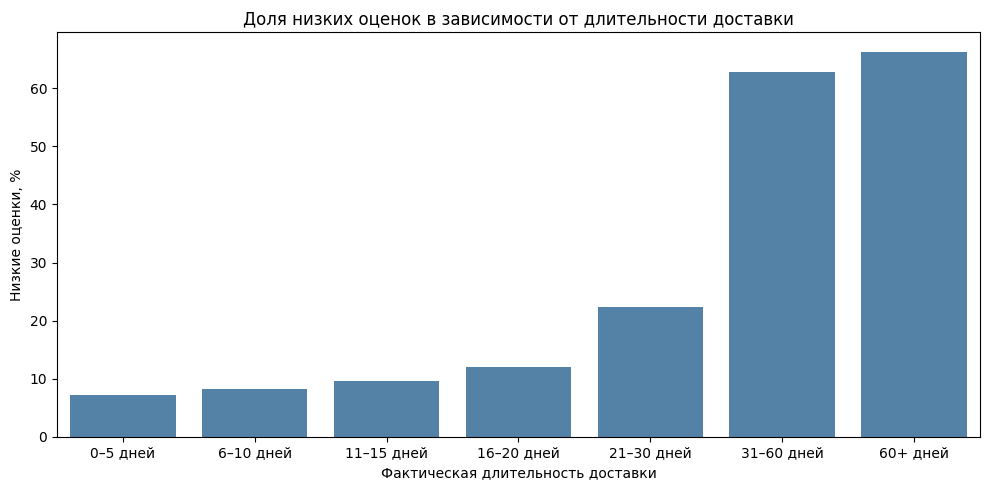

In [29]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=delivery_time_analysis,
    x="delivery_time_group",
    y="bad_review_percent",
    color="steelblue"
)

plt.title(
    "Доля низких оценок в зависимости от длительности доставки"
)
plt.xlabel("Фактическая длительность доставки")
plt.ylabel("Низкие оценки, %")

plt.tight_layout()
plt.show()

In [30]:
# Сравнение основных числовых признаков
# для хороших и низких оценок

numeric_eda = [
    "number_of_items",
    "total_price",
    "total_freight",
    "total_order_value",
    "avg_item_price",
    "avg_freight_value",
    "number_of_payments",
    "max_installments"
]

eda_summary = (
    df_model
    .groupby("bad_review")[numeric_eda]
    .mean()
    .T
)

eda_summary.columns = [
    "Хорошая оценка (3–5)",
    "Низкая оценка (1–2)"
]

display(eda_summary.round(2))

,Хорошая оценка (3–5),Низкая оценка (1–2)
number_of_items,1.12,1.32
total_price,133.40,159.91
total_freight,22.03,27.72
total_order_value,155.43,187.63
avg_item_price,124.06,131.73
avg_freight_value,19.95,21.46
number_of_payments,1.04,1.05
max_installments,2.89,3.18


Заказы с низкими оценками в среднем имеют несколько более высокую коммерческую нагрузку. Средняя стоимость заказа составляет 187.63 против 155.43 для заказов с оценками 3–5. Средняя стоимость доставки также выше: 27.72 против 22.03.

Кроме того, заказы с низкими оценками в среднем содержат больше товарных позиций (1.32 против 1.12) и имеют немного большее максимальное количество платежей в рассрочку (3.18 против 2.89).

При этом различия по количеству платежей практически отсутствуют: 1.05 против 1.04. Поэтому этот признак сам по себе, вероятно, содержит меньше информации для объяснения различий между группами.

In [31]:
# Доля низких оценок по штатам покупателей

state_analysis = (
    df_model
    .groupby("customer_state")["bad_review"]
    .agg(["count", "mean"])
    .reset_index()
)

state_analysis["bad_review_percent"] = (
    state_analysis["mean"] * 100
).round(2)

state_analysis = state_analysis.sort_values(
    "bad_review_percent",
    ascending=False
)

display(state_analysis)

,customer_state,count,mean,bad_review_percent
1,AL,394,0.213198,21.32
9,MA,712,0.199438,19.94
24,SE,334,0.188623,18.86
18,RJ,12211,0.183933,18.39
13,PA,933,0.181136,18.11
5,CE,1273,0.172820,17.28
4,BA,3229,0.170641,17.06
16,PI,471,0.161359,16.14
0,AC,80,0.150000,15.00
14,PB,512,0.148438,14.84


Доля низких оценок различается между штатами покупателей. Наиболее высокие значения наблюдаются в AL (21.32%), MA (19.94%), SE (18.86%) и RJ (18.39%), тогда как в SP доля составляет 10.71%. Однако результаты для штатов с небольшим количеством наблюдений следует интерпретировать осторожно. Штат покупателя может использоваться как дополнительный категориальный признак модели, но различия между регионами не следует трактовать как причинный эффект.

In [33]:
# Доля низких оценок по способу оплаты

payment_analysis = (
    df_model
    .groupby("payment_types")["bad_review"]
    .agg(["count", "mean"])
    .reset_index()
)

payment_analysis["bad_review_percent"] = (
    payment_analysis["mean"] * 100
).round(2)

payment_analysis = payment_analysis.sort_values(
    "bad_review_percent",
    ascending=False
)

display(payment_analysis)

,payment_types,count,mean,bad_review_percent
4,voucher,1483,0.144302,14.43
5,"voucher,credit_card",1076,0.131041,13.10
1,credit_card,71643,0.129140,12.91
2,"credit_card,voucher",1089,0.126722,12.67
0,boleto,19062,0.125957,12.60
3,debit_card,1478,0.110961,11.10


Доля низких оценок несколько различается в зависимости от способа оплаты. Наибольшая доля наблюдается для заказов, оплаченных только ваучером (14.43%), а наименьшая — для заказов с оплатой дебетовой картой (11.10%). При этом большинство заказов оплачено кредитной картой (71 643 наблюдения), поэтому различия для менее распространённых способов оплаты следует интерпретировать осторожно. Способ оплаты может использоваться как дополнительный признак при построении модели.

In [34]:
# Финальный список признаков для ML

features = [
    "number_of_items",
    "number_of_sellers",
    "number_of_categories",
    "total_price",
    "total_freight",
    "total_order_value",
    "avg_item_price",
    "avg_freight_value",
    "avg_product_weight",
    "avg_product_photos",
    "number_of_payments",
    "max_installments",
    "total_payment_value",
    "payment_types",
    "customer_state",
    "delivery_time_days",
    "delivery_delay_days"
]

target = "bad_review"

df_ml = df_model[features + [target]].copy()

print("Размер датасета для ML:", df_ml.shape)

print("\nКоличество признаков:", len(features))

print("\nПропуски:")
display(
    df_ml.isnull()
    .sum()
    .sort_values(ascending=False)
)

Размер датасета для ML: (95832, 18)

Количество признаков: 17

Пропуски:


,0
avg_product_photos,1324
avg_product_weight,16
delivery_time_days,8
delivery_delay_days,8
max_installments,1
number_of_payments,1
total_payment_value,1
payment_types,1
number_of_sellers,0
number_of_items,0


In [35]:
from sklearn.model_selection import train_test_split

X = df_ml.drop(columns="bad_review")
y = df_ml["bad_review"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)

print("\nРазмер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

print("\nДоля низких оценок в train:")
print(round(y_train.mean() * 100, 2), "%")

print("Доля низких оценок в test:")
print(round(y_test.mean() * 100, 2), "%")

Размер X_train: (76665, 17)
Размер X_test: (19167, 17)

Размер y_train: (76665,)
Размер y_test: (19167,)

Доля низких оценок в train:
12.85 %
Доля низких оценок в test:
12.84 %


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Числовые признаки
numeric_features = [
    "number_of_items",
    "number_of_sellers",
    "number_of_categories",
    "total_price",
    "total_freight",
    "total_order_value",
    "avg_item_price",
    "avg_freight_value",
    "avg_product_weight",
    "avg_product_photos",
    "number_of_payments",
    "max_installments",
    "total_payment_value",
    "delivery_time_days",
    "delivery_delay_days"
]

# Категориальные признаки
categorical_features = [
    "payment_types",
    "customer_state"
]

# Обработка числовых признаков
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Обработка категориальных признаков
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Общий preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))
print("Preprocessing подготовлен.")

Числовых признаков: 15
Категориальных признаков: 2
Preprocessing подготовлен.


In [37]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression успешно обучена!")

Logistic Regression успешно обучена!


In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Предсказание класса
y_pred_lr = logistic_model.predict(X_test)

# Вероятность низкой оценки
y_proba_lr = logistic_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba_lr):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy:  0.7658
Precision: 0.2935
Recall:    0.5849
F1-score:  0.3908
PR-AUC:    0.4102

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.86     16705
           1       0.29      0.58      0.39      2462

    accuracy                           0.77     19167
   macro avg       0.61      0.69      0.62     19167
weighted avg       0.85      0.77      0.80     19167


Confusion Matrix:
[[13238  3467]
 [ 1022  1440]]


In [39]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest успешно обучена!")

Random Forest успешно обучена!


In [40]:
# Предсказания Random Forest

y_pred_rf = random_forest_model.predict(X_test)

y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
Accuracy:  0.8580
Precision: 0.4522
Recall:    0.4972
F1-score:  0.4736
PR-AUC:    0.4791

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.92     16705
           1       0.45      0.50      0.47      2462

    accuracy                           0.86     19167
   macro avg       0.69      0.70      0.70     19167
weighted avg       0.86      0.86      0.86     19167


Confusion Matrix:
[[15222  1483]
 [ 1238  1224]]


In [41]:
import numpy as np

thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (
        y_proba_rf >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(3))

,threshold,precision,recall,f1_score
0,0.20,0.129,0.999,0.228
1,0.25,0.132,0.984,0.233
2,0.30,0.169,0.844,0.282
3,0.35,0.254,0.672,0.368
4,0.40,0.345,0.581,0.433
5,0.45,0.407,0.538,0.464
6,0.50,0.452,0.497,0.474
7,0.55,0.499,0.463,0.480
8,0.60,0.562,0.415,0.477
9,0.65,0.640,0.368,0.467


In [42]:
best_threshold = 0.55

print("Выбранный threshold:", best_threshold)
print("Причина: максимальный F1-score среди протестированных порогов.")

Выбранный threshold: 0.55
Причина: максимальный F1-score среди протестированных порогов.


In [43]:
# Финальные предсказания Random Forest
# с выбранным threshold = 0.55

y_pred_final = (
    y_proba_rf >= best_threshold
).astype(int)

print("=== Random Forest с threshold = 0.55 ===")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_final):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

=== Random Forest с threshold = 0.55 ===
Accuracy:  0.8712
Precision: 0.4987
Recall:    0.4630
F1-score:  0.4802
PR-AUC:    0.4791

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93     16705
           1       0.50      0.46      0.48      2462

    accuracy                           0.87     19167
   macro avg       0.71      0.70      0.70     19167
weighted avg       0.87      0.87      0.87     19167


Confusion Matrix:
[[15559  1146]
 [ 1322  1140]]


In [44]:
# Получаем обученный preprocessing
preprocessor_fitted = (
    random_forest_model
    .named_steps["preprocessor"]
)

# Названия признаков после preprocessing
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

# Важность признаков Random Forest
importances = (
    random_forest_model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

# Топ-15 признаков
top_features = feature_importance.head(15).copy()

top_features["importance_percent"] = (
    top_features["importance"] * 100
).round(2)

display(
    top_features[
        ["feature", "importance_percent"]
    ]
)

,feature,importance_percent
14,num__delivery_delay_days,30.61
13,num__delivery_time_days,24.40
0,num__number_of_items,6.31
4,num__total_freight,5.65
7,num__avg_freight_value,4.27
6,num__avg_item_price,4.06
12,num__total_payment_value,3.91
5,num__total_order_value,3.85
8,num__avg_product_weight,3.66
3,num__total_price,3.37


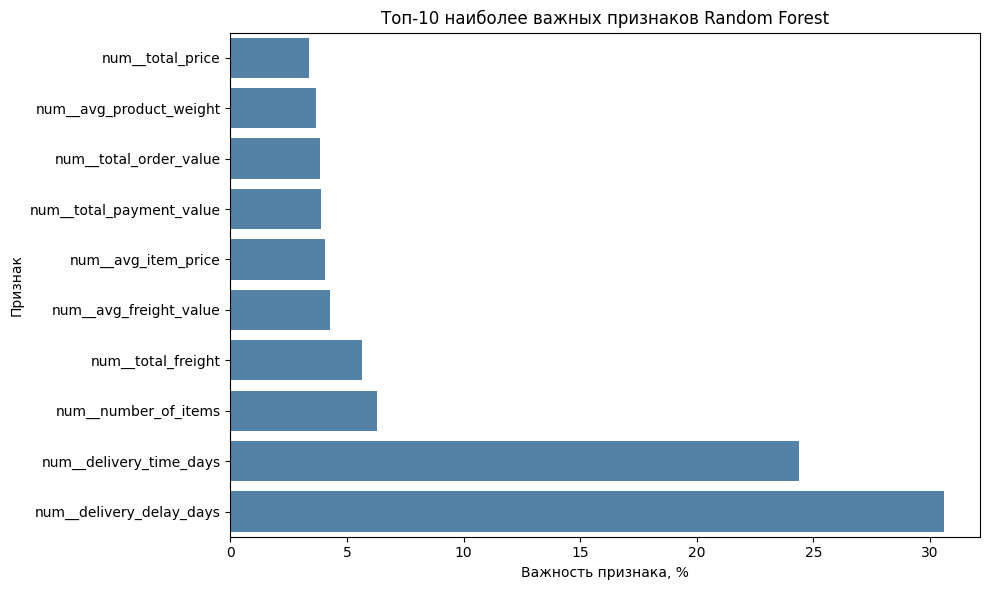

In [45]:
top_10 = (
    feature_importance
    .head(10)
    .sort_values("importance")
    .copy()
)

top_10["importance_percent"] = (
    top_10["importance"] * 100
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10,
    x="importance_percent",
    y="feature",
    color="steelblue"
)

plt.title(
    "Топ-10 наиболее важных признаков Random Forest"
)
plt.xlabel("Важность признака, %")
plt.ylabel("Признак")

plt.tight_layout()
plt.show()

In [46]:
final_comparison = pd.DataFrame({
    "Модель": [
        "Logistic Regression",
        "Random Forest (threshold = 0.55)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_final)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_final)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_final)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_final)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_proba_lr),
        average_precision_score(y_test, y_proba_rf)
    ]
})

display(final_comparison.round(4))

,Модель,Accuracy,Precision,Recall,F1-score,PR-AUC
0,Logistic Regression,0.7658,0.2935,0.5849,0.3908,0.4102
1,Random Forest (threshold = 0.55),0.8712,0.4987,0.4630,0.4802,0.4791


In [47]:
print("Признаки, использованные в модели:")
for i, feature in enumerate(X.columns, 1):
    print(f"{i:2}. {feature}")

print("\nЦелевая переменная:")
print("bad_review")

print("\nПроверка:")
print("review_score есть среди X?", "review_score" in X.columns)
print("bad_review есть среди X?", "bad_review" in X.columns)

Признаки, использованные в модели:
 1. number_of_items
 2. number_of_sellers
 3. number_of_categories
 4. total_price
 5. total_freight
 6. total_order_value
 7. avg_item_price
 8. avg_freight_value
 9. avg_product_weight
10. avg_product_photos
11. number_of_payments
12. max_installments
13. total_payment_value
14. payment_types
15. customer_state
16. delivery_time_days
17. delivery_delay_days

Целевая переменная:
bad_review

Проверка:
review_score есть среди X? False
bad_review есть среди X? False


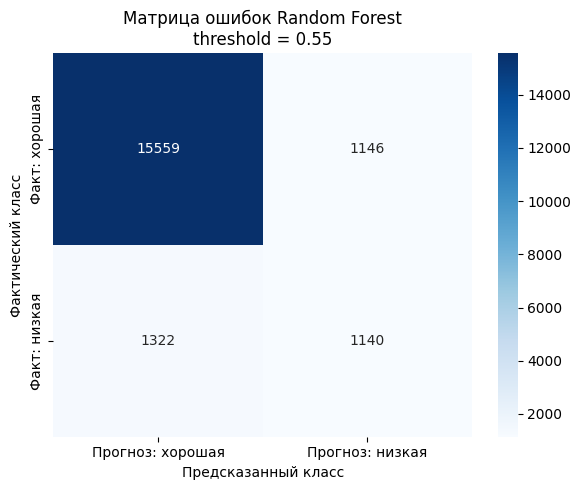

In [48]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Прогноз: хорошая", "Прогноз: низкая"],
    yticklabels=["Факт: хорошая", "Факт: низкая"]
)

plt.title(
    "Матрица ошибок Random Forest\n"
    "threshold = 0.55"
)

plt.xlabel("Предсказанный класс")
plt.ylabel("Фактический класс")

plt.tight_layout()
plt.show()

In [49]:
import sqlite3
import pandas as pd

db_path = "/content/olist.db"

conn = sqlite3.connect(db_path)

# Проверяем список таблиц
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name
    """,
    conn
)

print("Таблицы в SQLite:")
display(tables)

# Проверяем количество строк в основных таблицах
table_names = [
    "customers",
    "geolocation",
    "order_items",
    "order_payments",
    "order_reviews",
    "orders",
    "products",
    "sellers",
    "category_translation"
]

print("\nКоличество строк:")

for table in table_names:
    result = pd.read_sql_query(
        f"SELECT COUNT(*) AS rows_count FROM {table}",
        conn
    )
    print(f"{table:22} {result.iloc[0, 0]:,}")

conn.close()

Таблицы в SQLite:


,name
0,category_translation
1,customers
2,geolocation
3,order_items
4,order_payments
5,order_reviews
6,orders
7,products
8,sellers



Количество строк:
customers              99,441
geolocation            1,000,163
order_items            112,650
order_payments         103,886
order_reviews          99,224
orders                 99,441
products               32,951
sellers                3,095
category_translation   71


In [50]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("/content/olist.db")

sql_check = """
SELECT
    o.order_id,
    o.customer_id,
    c.customer_state,
    COUNT(DISTINCT oi.product_id) AS number_of_items,
    COUNT(DISTINCT oi.seller_id) AS number_of_sellers,
    ROUND(SUM(oi.price), 2) AS total_price,
    ROUND(SUM(oi.freight_value), 2) AS total_freight,
    ROUND(AVG(oi.price), 2) AS avg_item_price
FROM orders AS o
LEFT JOIN customers AS c
    ON o.customer_id = c.customer_id
LEFT JOIN order_items AS oi
    ON o.order_id = oi.order_id
GROUP BY
    o.order_id,
    o.customer_id,
    c.customer_state
LIMIT 10;
"""

sql_result = pd.read_sql_query(sql_check, conn)

display(sql_result)

conn.close()

,order_id,customer_id,customer_state,number_of_items,number_of_sellers,total_price,total_freight,avg_item_price
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,RJ,1,1,58.90,13.29,58.90
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,SP,1,1,239.90,19.93,239.90
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,MG,1,1,199.00,17.87,199.00
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,SP,1,1,12.99,12.79,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,SP,1,1,199.90,18.14,199.90
5,00048cc3ae777c65dbb7d2a0634bc1ea,816cbea969fe5b689b39cfc97a506742,MG,1,1,21.90,12.69,21.90
6,00054e8431b9d7675808bcb819fb4a32,32e2e6ab09e778d99bf2e0ecd4898718,SP,1,1,19.90,11.85,19.90
7,000576fe39319847cbb9d288c5617fa6,9ed5e522dd9dd85b4af4a077526d8117,SP,1,1,810.00,70.75,810.00
8,0005a1a1728c9d785b8e2b08b904576c,16150771dfd4776261284213b89c304e,SP,1,1,145.95,11.65,145.95
9,0005f50442cb953dcd1d21e1fb923495,351d3cb2cee3c7fd0af6616c82df21d3,SP,1,1,53.99,11.40,53.99


In [51]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("/content/olist.db")

sql_check = """
SELECT
    o.order_id,
    o.customer_id,
    c.customer_state,
    COUNT(DISTINCT oi.product_id) AS number_of_items,
    COUNT(DISTINCT oi.seller_id) AS number_of_sellers,
    ROUND(SUM(oi.price), 2) AS total_price,
    ROUND(SUM(oi.freight_value), 2) AS total_freight,
    ROUND(AVG(oi.price), 2) AS avg_item_price
FROM orders AS o
LEFT JOIN customers AS c
    ON o.customer_id = c.customer_id
LEFT JOIN order_items AS oi
    ON o.order_id = oi.order_id
GROUP BY
    o.order_id,
    o.customer_id,
    c.customer_state
LIMIT 10;
"""

sql_result = pd.read_sql_query(sql_check, conn)

print("Размер результата:", sql_result.shape)
print("Названия столбцов:")
print(sql_result.columns.tolist())

display(sql_result)

conn.close()

Размер результата: (10, 8)
Названия столбцов:
['order_id', 'customer_id', 'customer_state', 'number_of_items', 'number_of_sellers', 'total_price', 'total_freight', 'avg_item_price']


,order_id,customer_id,customer_state,number_of_items,number_of_sellers,total_price,total_freight,avg_item_price
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,RJ,1,1,58.90,13.29,58.90
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,SP,1,1,239.90,19.93,239.90
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,MG,1,1,199.00,17.87,199.00
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,SP,1,1,12.99,12.79,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,SP,1,1,199.90,18.14,199.90
5,00048cc3ae777c65dbb7d2a0634bc1ea,816cbea969fe5b689b39cfc97a506742,MG,1,1,21.90,12.69,21.90
6,00054e8431b9d7675808bcb819fb4a32,32e2e6ab09e778d99bf2e0ecd4898718,SP,1,1,19.90,11.85,19.90
7,000576fe39319847cbb9d288c5617fa6,9ed5e522dd9dd85b4af4a077526d8117,SP,1,1,810.00,70.75,810.00
8,0005a1a1728c9d785b8e2b08b904576c,16150771dfd4776261284213b89c304e,SP,1,1,145.95,11.65,145.95
9,0005f50442cb953dcd1d21e1fb923495,351d3cb2cee3c7fd0af6616c82df21d3,SP,1,1,53.99,11.40,53.99


**Финальные выводы **

В рамках проекта была построена модель для прогнозирования низкой оценки заказа (1–2 звезды) на основе данных, доступных после завершения доставки и до публикации клиентом отзыва.

После фильтрации доставленных заказов и исключения заказов без оценки в итоговой выборке осталось 95 832 заказа. Низкие оценки составили 12,85% наблюдений, поэтому задача характеризуется дисбалансом классов.

Для решения задачи были обучены две модели классификации: Logistic Regression и Random Forest. Для оценки качества использовались Precision, Recall, F1-score и PR-AUC, поскольку при наличии дисбаланса классов одной Accuracy недостаточно для оценки качества прогнозирования низких оценок.

Random Forest показала PR-AUC 0,4791 и F1-score 0,4802 при выбранном пороге классификации 0,55. Logistic Regression показала PR-AUC 0,4102 и F1-score 0,3908. Таким образом, модели продемонстрировали разные характеристики по Precision и Recall, а Random Forest обеспечила более высокое значение F1-score и PR-AUC на тестовой выборке.

Анализ важности признаков Random Forest показал, что наиболее информативными признаками являются задержка доставки относительно обещанной даты (delivery_delay_days) и общая длительность доставки (delivery_time_days). Их суммарная важность составляет около 55% в модели. Также заметный вклад имеют количество товаров в заказе, стоимость доставки и характеристики стоимости товаров.

Результаты EDA согласуются с результатами модели: доля низких оценок заметно увеличивается при существенном опоздании доставки. Например, для заказов, доставленных на 8–14 дней позже ожидаемой даты, доля низких оценок составляет около 78%, а при опоздании более чем на 14 дней — около 79%.

С точки зрения бизнеса модель может использоваться как инструмент раннего выявления заказов с повышенным риском негативной оценки. После завершения доставки система может сформировать список заказов с высокой прогнозируемой вероятностью низкой оценки и передать его в систему клиентского сервиса для дальнейшей работы с клиентом.

При этом модель не определяет причинно-следственные связи. Высокая важность признака означает, что он является информативным для прогнозирования в рамках данной модели, но не доказывает, что именно изменение этого фактора приведёт к изменению оценки клиента.

Кроме того, выбранный сценарий прогнозирования предполагает, что фактическая дата доставки уже известна, а отзыв клиента ещё не оставлен. Поэтому модель следует интерпретировать как инструмент прогнозирования риска негативной оценки в момент после доставки и до появления отзыва.